# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep 2     |  |
| :-------------|:-------------|
| Chinming Zhu| 6325971 |
| Annet Moeleker| 6300316 |
| Daan van der Molen| 6530095 |

| Planning Groep: 2     |Tijdstip / Tijdspanne  |
|---|---|
| synthese: schetsing meetopstellingen|11:30|
| evaluatie: Criteria opgesteld | 12:30 |
| simulatie: Eerste kalibratie meting gedaan| 13:00 |
|pauze 1|13:00-13:30|
| eerste meting| 14:00 |
| data verwerking| 14:45 |
|iteratie|15:45|
|conclusie trekken|16:30|
|template in orde maken|16:45|
|inleveren brightspace|17:00|
|feedback geven| 17:15|
|opruimen|17:30|

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](schetsen.jpg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|LDR | lamp die de lichtintensiteit constant houd | 10% lux onzekerheid, meetbereik 100-600 lux |
|krachtsensor | keukenweegschaal | 10% onzekerheidsmarge en range van 10-5000 gram, opp max 100cm2 |
|temperatuur | sensor voor ventilator, die harder gaat bij hogere temperatuur | range 15-40c, stand 1 boven 25C, stand 2 boven 30C, stand 3 boven 35c, onzekerheid van 1 graden |

Groep 2 heeft gekozen voor de LDR. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](meetopstelling.jpg "schets meetopstelling student")
 ![Alt](schakeling.jpg "schets schakeling student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? \
We veranderen de hoogte van het karton. Hierdoor verandert de hoeveelheid licht die op de sensoren valt.
Ook worden er metingen gedaan in de duisternis en zonder karton boven de opstelling. 
2. Over welk bereik ga je deze variabelen veranderen? \
Tussen 0 lx en 700 lx. 

3. Wat ga je allemaal meten? \
De lichtintensiteit van de lichtsensor van de telefoon in lx en de bijbehorende meting van de Arduino lichtsensor in bits.
4. Hoeveel metingen ga je doen? \
10 metingen, elke meting duurt ongeveer 10 seconden lang tot de waarde ongeveer stabiel is.
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen? \
De toepassing gaat over de lichtintensiteit in een ruimte. Tussen een donkere ruimte en een goed verlichte ruimte zit de lichtintensiteit ongeveer tussen de 0 en 700 lx. 


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](meetopstelling1.jpg "meetopstelling student")
 ![Alt](meetopstelling2.jpg "meetopstelling student")

## *Opdracht 6*: Meten en fitten, Leerdoel

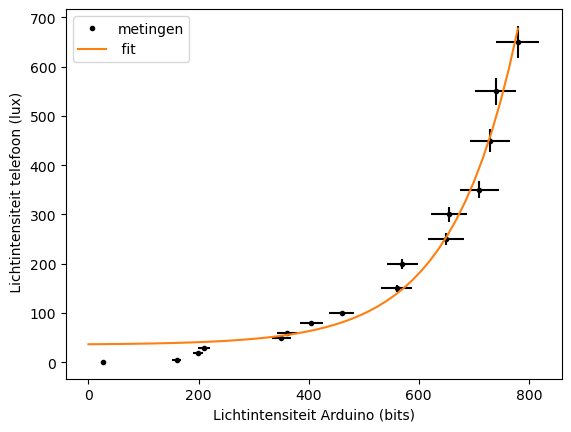

a = 1.008321 +/- 5.2e-05 b = 35.7782 +/- 9.8652
40.22193343499985


In [1]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data_tel = np.array([650,550,450,350,300,250,200,150,100,80,60,50,30,20,5,1])
data_ard = np.array([780,740,730,710,655,650,570,560,460,405,360,350,210,199,160,27])

def func_fit(x, a,b):
    return a**x+b
val,cov = curve_fit(func_fit,data_ard,data_tel, maxfev=10000)
a_error,b_error=np.sqrt(np.diag(cov))
ard_fit=np.linspace(0,max(data_ard))
y_fit=func_fit(ard_fit,*val)
plt.figure()
plt.xlabel('Lichtintensiteit Arduino (bits)' )
plt.ylabel(' Lichtintensiteit telefoon (lux)' )
plt.errorbar(data_ard,data_tel,xerr=0.05*data_ard,yerr=0.05*data_tel, fmt=' ', ecolor='black' )
plt.plot(data_ard,data_tel,'k.',label='metingen')
plt.plot(ard_fit,y_fit, label=' fit')
plt.legend()
plt.show()

print('a =',round(val[0],6),'+/-', round(a_error,6), 'b =',round(val[1],4), '+/-', round(b_error,4))
print(func_fit(180,*val))

## *Opdracht 7*: Iteratie nodig?

We hebben de doos beter lichtdicht gemaakt, meer meetpunten toegevoegd en linialen toegevoegd, zodat de hoogte nauwkeuriger en stabieler bepaald wordt. 

## *Opdracht 8*: Conclusie, leerdoel

De grafiek volgt de exponentiele fitlijn binnen het meetbereik (0-600 lux) erg goed. De gekalibreerde sensor voldoet aan de criteria voor onze toepassing, want het meetbereik is tussen de 0 en 600 lux met een nauwkeurigheid van minder dan 10% wat bleek uit een testmeting en te zien is in de grafiek. 

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

 ![Alt](schakeling.jpg "schets schakeling student")


### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|LDR | lamp die de lichtintensiteit constant houd | 10% lux onzekerheid, meetbereik 100-600 lux |
|krachtsensor | keukenweegschaal | 10% onzekerheidsmarge en range van 10-5000 gram, opp max 100cm2 |
|temperatuur | sensor voor ventilator, die harder gaat bij hogere temperatuur | range 15-40c, stand 1 boven 25C, stand 2 boven 30C, stand 3 boven 35c, onzekerheid van 1 graden |

Groep 2 heeft gekozen voor de LDR. 

Iteratie:

We hebben de doos beter lichtdicht gemaakt, meer meetpunten toegevoegd en linialen toegevoegd, zodat de hoogte nauwkeuriger en stabieler bepaald wordt. 

## *Opdracht 8*: Conclusie, leerdoel

Uit de kalibratie van de sensor volgt een duidelijk exponentieel verband. De gekalibreerde sensor voldoet aan de criteria voor onze toepassing, want het meetbereik is tussen de 0 en 600 lux met een nauwkeurigheid van minder dan 10%. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

![Alt](meetopstelling2.jpg "meetopstelling student")

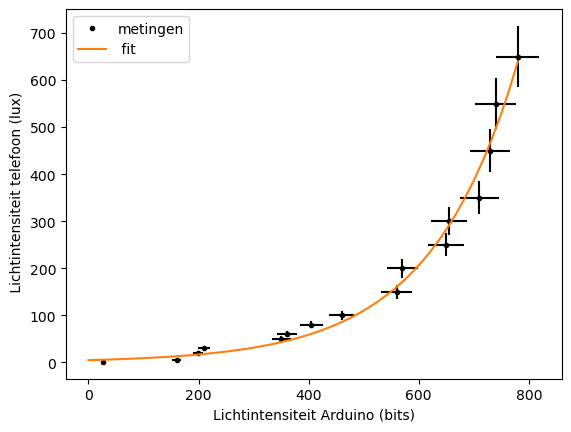

a = 4.748029765086883 b = 1.0063052341502923


In [2]:
# Zet hier jouw data in een voor jou handig formaat
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data_tel = np.array([650,550,450,350,300,250,200,150,100,80,60,50,30,20,5,1])
data_ard = np.array([780,740,730,710,655,650,570,560,460,405,360,350,210,199,160,27])

def func_fit(x, a,b):
    return a*b**x
val,cov = curve_fit(func_fit,data_ard,data_tel, maxfev=10000)
ard_fit=np.linspace(0,max(data_ard))
y_fit=func_fit(ard_fit,*val)
plt.figure()
plt.xlabel('Lichtintensiteit Arduino (bits)' )
plt.ylabel(' Lichtintensiteit telefoon (lux)' )
plt.errorbar(data_ard,data_tel,xerr=0.05*data_ard,yerr=0.1*data_tel, fmt=' ', ecolor='black' )
plt.plot(data_ard,data_tel,'k.',label='metingen')
plt.plot(ard_fit,y_fit, label=' fit' )

plt.legend()
plt.show()

print('a =',val[0],'b =',val[1])
#print(func_fit(180,*val))